# **1. Import neccessary Libraries**
---

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
data= pd.read_csv("/content/seasonal_agriculture_performance_dataset.csv")

# **2. Explore and understand the dataset.**
---

In [ ]:
# Basic Analysis
df= pd.DataFrame(data)
df.head()
df.tail()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

# **3. Identify Duplicates**

---



In [ ]:
# Identify and drop duplicate records
duplicates_count = df.duplicated().sum()
print(f"Duplicate records found: {duplicates_count}")

if duplicates_count > 0:
    df.drop_duplicates(inplace=True)
    print("Duplicates removed.")

Duplicate records found: 0


# **4. Descriptive / Statistical Analysis**

---



In [ ]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


# **5. Clean and prepare the data for analysis**.
---


# **🔎  Identify Outliers**
---

In [ ]:
# Sirf numeric columns ko filter karenge
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("Outliers count per column at initial stage:\n")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    if len(outliers) > 0:
        print(f"{col}: {len(outliers)} outliers")

Outliers count per column at initial stage:

Avg_Temperature_C: 2 outliers
Humidity_pct: 6 outliers
Sunlight_Hours_Day: 26 outliers
Soil_Moisture_pct: 3 outliers
Nitrogen_kg_ha: 10 outliers
Phosphorus_kg_ha: 16 outliers
Potassium_kg_ha: 32 outliers
Fertilizer_kg_ha: 15 outliers
Pesticide_Litre_ha: 8 outliers
Yield_Tonnes_Ha: 302 outliers
Production_Tonnes: 333 outliers
Revenue_INR: 240 outliers
Profit_INR: 404 outliers
Water_Used_m3: 276 outliers
Water_Efficiency_t_per_1000m3: 322 outliers
Disease_Pest_Risk_pct: 10 outliers


# **🔎 Remove Outliers**

---

In [ ]:
#Remove the Outlier
Q1 = df['Yield_Tonnes_Ha'].quantile(0.25)
Q3 = df['Yield_Tonnes_Ha'].quantile(0.75)

IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_clean = df[(df['Yield_Tonnes_Ha'] >= lower_bound) & (df['Yield_Tonnes_Ha'] <= upper_bound)].copy()

print("Original Data Rows:", df.shape[0])
print("Clean Data Rows (After removing outliers):", df_clean.shape[0])
print("New Maximum Yield is:", df_clean['Yield_Tonnes_Ha'].max())
df_clean.describe().transpose()

Original Data Rows: 4000
Clean Data Rows (After removing outliers): 3666
New Maximum Yield is: 5.44


,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,3666.0,7.858014,4.226954,0.500,4.22250,7.8800,11.6075,15.000
Rainfall_mm,3621.0,602.722977,288.704499,80.000,371.00000,583.9000,836.1000,1395.200
Avg_Temperature_C,3666.0,26.826405,3.820676,16.200,23.90000,26.9000,29.6000,39.700
Humidity_pct,3666.0,63.332106,11.969774,25.000,55.00000,63.1000,72.0000,95.000
Sunlight_Hours_Day,3666.0,7.320322,1.119054,3.500,6.60000,7.3000,8.1000,11.000
Soil_pH,3666.0,6.706476,0.648763,5.200,6.26000,6.7000,7.1400,8.400
Soil_Moisture_pct,3632.0,26.558150,6.673726,8.000,21.90000,26.5000,31.3000,46.400
Nitrogen_kg_ha,3666.0,119.944763,31.076622,40.000,98.40000,119.7500,140.8000,220.000
Phosphorus_kg_ha,3666.0,57.651146,17.009799,15.000,46.10000,57.4000,69.3000,120.000
Potassium_kg_ha,3666.0,104.707774,27.776123,30.000,85.90000,105.0500,123.7000,200.000


# **6. Handled Missing Values**
---

In [ ]:
#Before
print("Missing values before cleaning:\n",df_clean.isnull().sum())

#filling missing values with their mean value
df_clean['Rainfall_mm']=df_clean['Rainfall_mm'].fillna(df_clean['Rainfall_mm'].mean())
df_clean['Soil_Moisture_pct']=df_clean['Soil_Moisture_pct'].fillna(df_clean['Soil_Moisture_pct'].mean())
df_clean['Yield_Tonnes_Ha']=df_clean['Yield_Tonnes_Ha'].fillna(df_clean['Yield_Tonnes_Ha'].mean())

#After
print("Missing values after cleaning:\n",df_clean.isnull().sum())

Missing values before cleaning:
 Farm_ID                           0
State                             0
District                          0
Crop                              0
Season                            0
Farm_Area_Hectares                0
Rainfall_mm                      45
Avg_Temperature_C                 0
Humidity_pct                      0
Sunlight_Hours_Day                0
Soil_pH                           0
Soil_Moisture_pct                34
Nitrogen_kg_ha                    0
Phosphorus_kg_ha                  0
Potassium_kg_ha                   0
Irrigation_Method                 0
Fertilizer_kg_ha                  0
Pesticide_Litre_ha                0
Seed_Quality_Score                0
Yield_Tonnes_Ha                   0
Production_Tonnes                 0
Market_Price_INR_Tonne            0
Total_Cost_INR                    0
Revenue_INR                       0
Profit_INR                        0
Water_Used_m3                     0
Water_Efficiency_t_per_1000m3  

# **7. Agricultural performance varies across seasons.**

---


In [ ]:
#Group_by season_find_profit&yield
seasonal_summary = df.groupby('Season')[['Profit_INR', 'Yield_Tonnes_Ha']].mean()
print(seasonal_summary.round(2))

        Profit_INR  Yield_Tonnes_Ha
Season                             
Kharif   178914.65             5.64
Rabi      87689.47             5.08
Zaid     -24804.82             4.67


# **8. Seasonal Comparison**
---
*   **Objective Achieved:** A structured statistical comparison across seasons.  
*   **Observation:** Aggregated metrics reveal the exact quantitative differences in profitability, resource usage, and overall production volume between Kharif, Rabi, and Zaid.

In [ ]:
season_metrics = df_clean.groupby("Season").agg(
    Records=("Farm_ID", "count"),
    Average_Yield=("Yield_Tonnes_Ha", "mean"),
    Total_Production=("Production_Tonnes", "sum"),
    Average_Profit=("Profit_INR", "mean"),
    Total_Profit=("Profit_INR", "sum"),
    Average_Water_Used=("Water_Used_m3", "mean")
).round(2)

season_metrics

,Records,Average_Yield,Total_Production,Average_Profit,Total_Profit,Average_Water_Used
Season,,,,,,
Kharif,1643,2.00,26288.20,112889.20,185476951,5537.13
Rabi,1483,1.75,20184.13,32050.59,47531021,5166.82
Zaid,540,1.47,6287.04,-85237.01,-46027983,5652.62


# **9. Average Profit by Seasons**
---


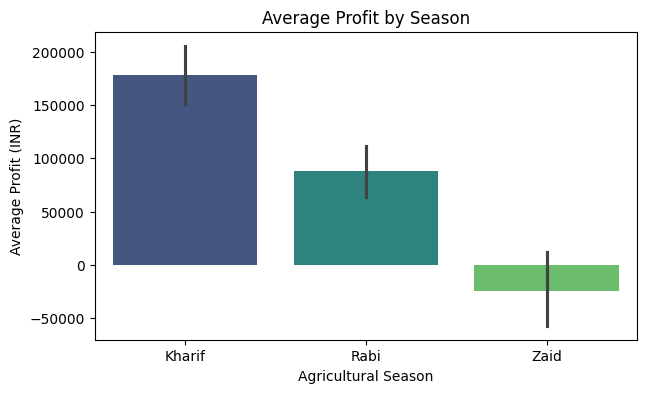

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(data=df, x='Season', y='Profit_INR', hue='Season', palette='viridis', legend=False)

plt.title('Average Profit by Season')
plt.xlabel('Agricultural Season')
plt.ylabel('Average Profit (INR)')
plt.show()

# **10. Distribution of Average Temperature (Univariate Analysis)**
---
*   **Objective Achieved:**
Completed Univariate Analysis for environmental conditions (Avg_Temperature_C).
*   **Observation:** The temperature distribution is slightly skewed or clustered around certain temperature zones, representing the most common weather conditions across the surveyed farms.
*   **Interpretation:** Helps establish the baseline environmental operating conditions for the majority of agricultural activities in this dataset.

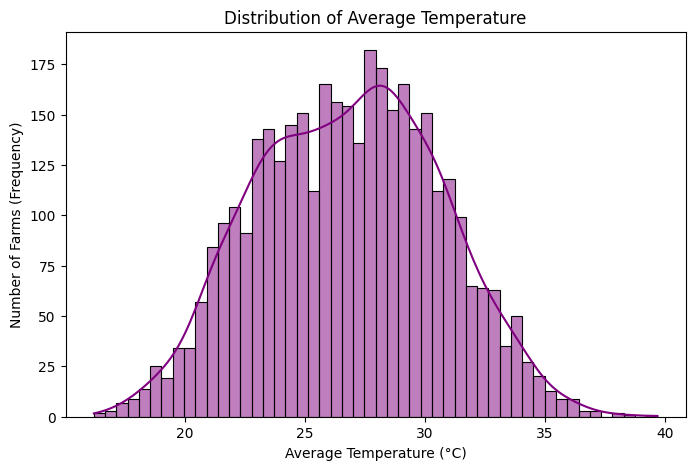

In [ ]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df_clean, x='Avg_Temperature_C', kde=True, color='purple', bins=50)
plt.title('Distribution of Average Temperature')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Number of Farms (Frequency)')
plt.show()

# **11. Relationship Between Rainfall and Crop Yield (Bivariate Analysis)**
---

*   **Objective Achieved:**
Visualized the relationship between environmental conditions (Rainfall) and agricultural outcomes (Yield) across different seasons.
*   **Key Insight 1:** Strict seasonal dependency is evident. Kharif crops strictly require high rainfall zones (600mm - 1400mm), whereas Rabi and Zaid thrive in lower rainfall zones (100mm - 600mm).
*   **Key Insight 2:** Higher rainfall does not guarantee higher yield. The data shows that yield remains within a specific range (0.5 to 5.5 Tonnes/Ha) regardless of rainfall volume, indicating other factors (soil, fertilizer) play a critical role.
*  **Recommendation**: For drought-prone or low-rainfall regions (200mm - 400mm), farmers should be advised to cultivate Rabi or Zaid crops to maximize yield potential up to 5 Tonnes/Ha.

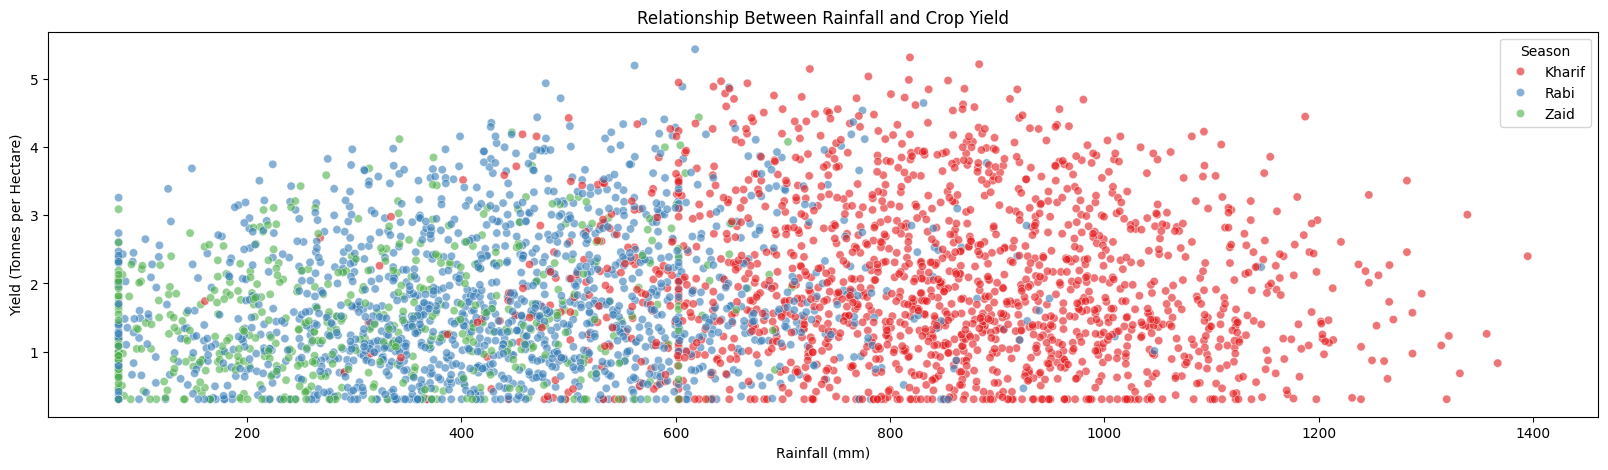

In [ ]:
plt.figure(figsize=(20, 5))

sns.scatterplot(data=df_clean, x='Rainfall_mm', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6, palette='Set1')

plt.title('Relationship Between Rainfall and Crop Yield')
plt.xlabel('Rainfall (mm)')
plt.ylabel('Yield (Tonnes per Hectare)')

plt.show()

# **12. Key Metrics by Season (Multivariate Analysis)**
---
*   **Objective Achieved:** Completed Multivariate Analysis by visualizing the interplay of multiple continuous variables (Temperature, Rainfall, Yield, Profit) simultaneously, categorized by Season.
*   **Observation:** The diagonal shows the density distribution (KDE) of each metric per season. The off-diagonal scatter plots reveal complex, multi-dimensional groupings—for instance, how specific temperature and rainfall combinations together dictate the Yield capacity of a particular Season.



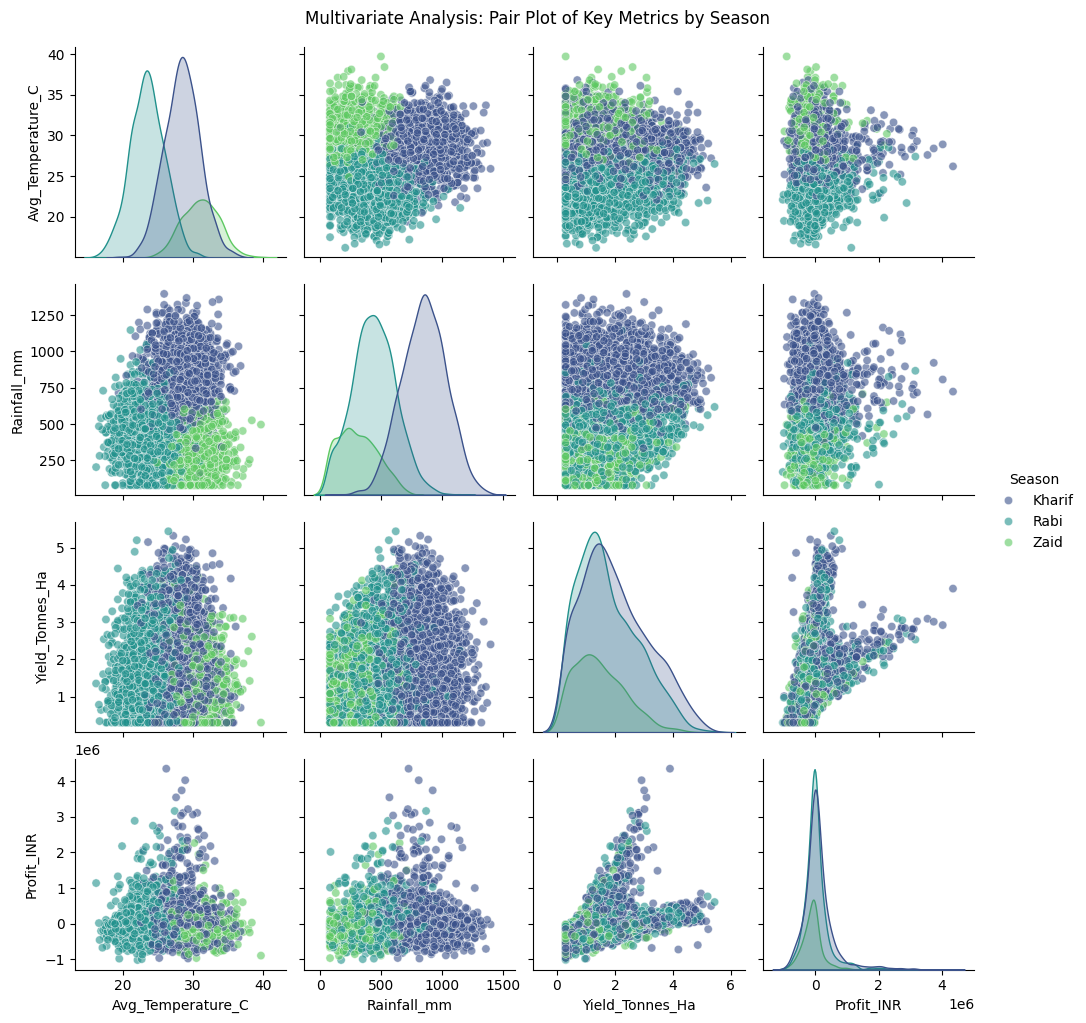

In [ ]:
selected_columns = ['Avg_Temperature_C', 'Rainfall_mm', 'Yield_Tonnes_Ha', 'Profit_INR', 'Season']

sns.pairplot(df_clean[selected_columns], hue='Season', palette='viridis', plot_kws={'alpha': 0.6})

plt.suptitle('Multivariate Analysis: Pair Plot of Key Metrics by Season', y=1.02)
plt.show()

# **13. Correlation Heatmap of Agricultural Variables**
---
*   **Objective Achieved:**
Generated a correlation matrix to instantly identify hidden relationships across all numerical variables in the dataset.
*   **Logic Used:** Applied Pearson correlation to extract the numerical dependency between inputs (e.g., fertilizer, water usage) and final economic outcomes (Revenue, Profit).

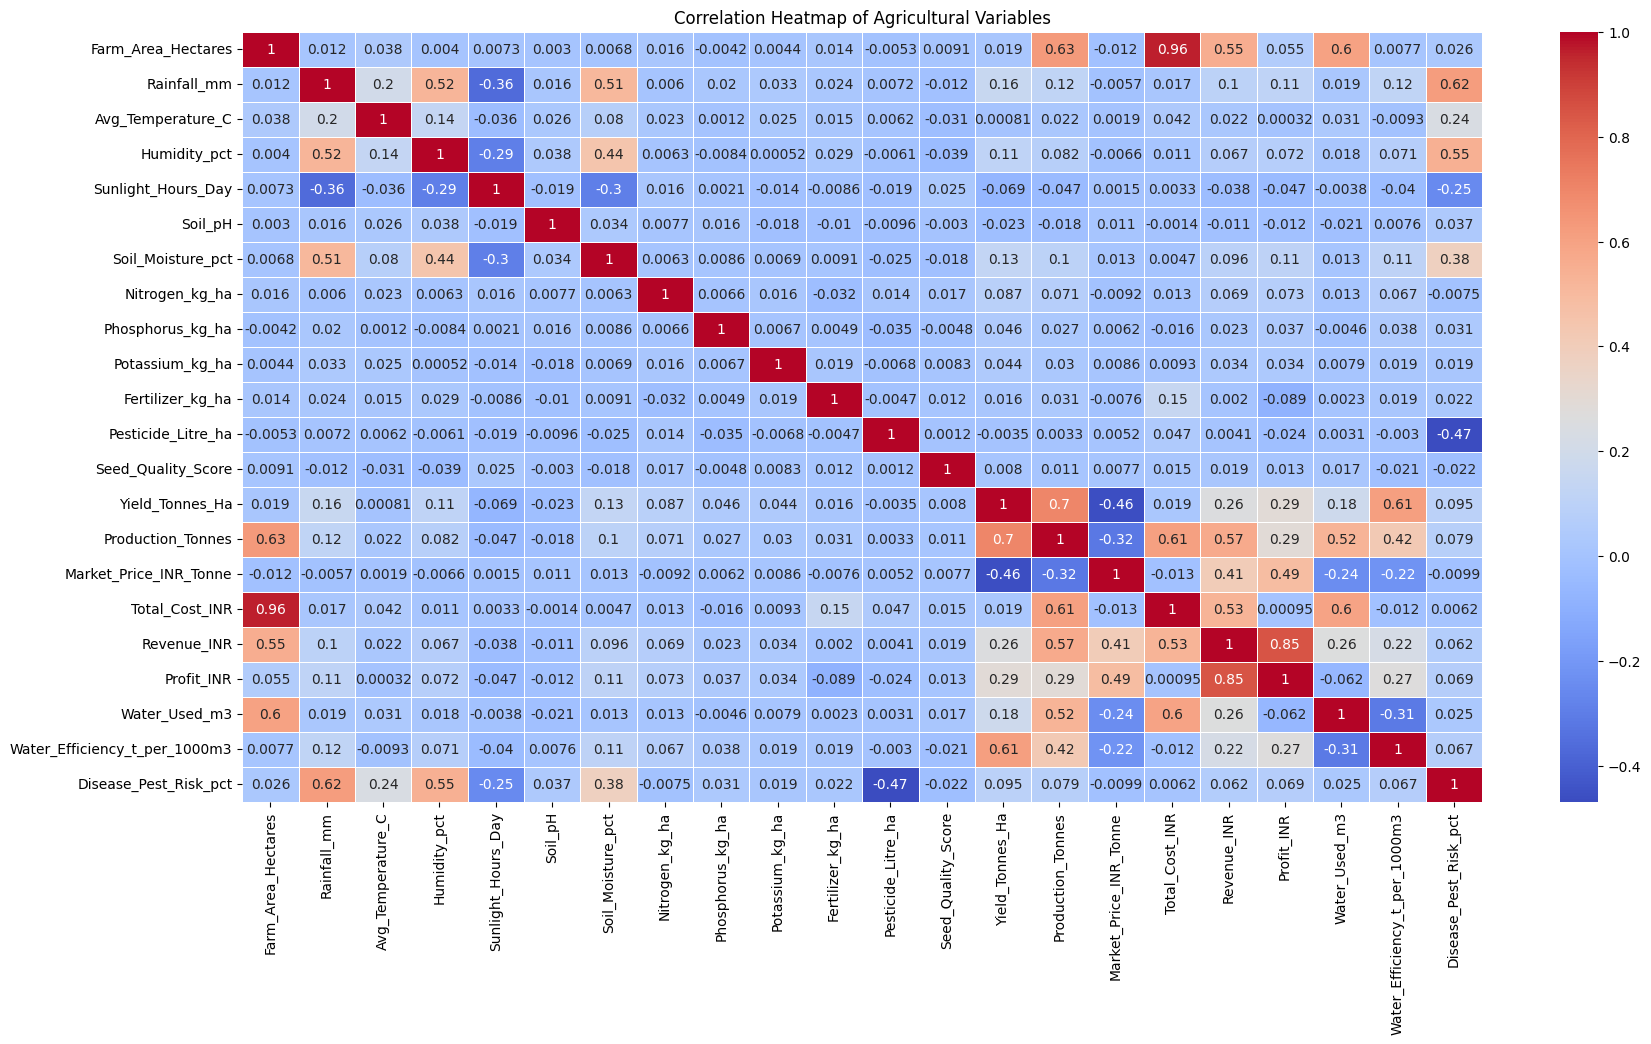


Top factors correlated with Profit:

Profit_INR                1.000000
Revenue_INR               0.848886
Market_Price_INR_Tonne    0.488821
Production_Tonnes         0.292582
Yield_Tonnes_Ha           0.290778
Name: Profit_INR, dtype: float64


In [ ]:
numeric_data = df_clean.select_dtypes(include=[np.number])

corr_matrix = numeric_data.corr()

plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5)

plt.title('Correlation Heatmap of Agricultural Variables')
plt.show()

print("\nTop factors correlated with Profit:\n")
print(corr_matrix['Profit_INR'].sort_values(ascending=False).head(5))

# **14. Variation in Water Usage Across Seasons**
---
*   **Objective Achieved:**
Examined differences in resource usage, specifically water consumption, across different agricultural seasons.
*   **Observation:** The visualization highlights noticeable variations in water requirements, with certain seasons (like Kharif) demanding significantly higher water volumes due to the nature of the crops cultivated.
*   **Recommendation:**
The boxplot reveals significant outliers in water usage across all three seasons, with some farms consuming over 30,000 cubic meters. To improve overall Profit_INR, a key recommendation is to target these high-consumption farms and implement modern, efficient irrigation methods (like Drip or Sprinkler systems) universally, rather than focusing on just one season.


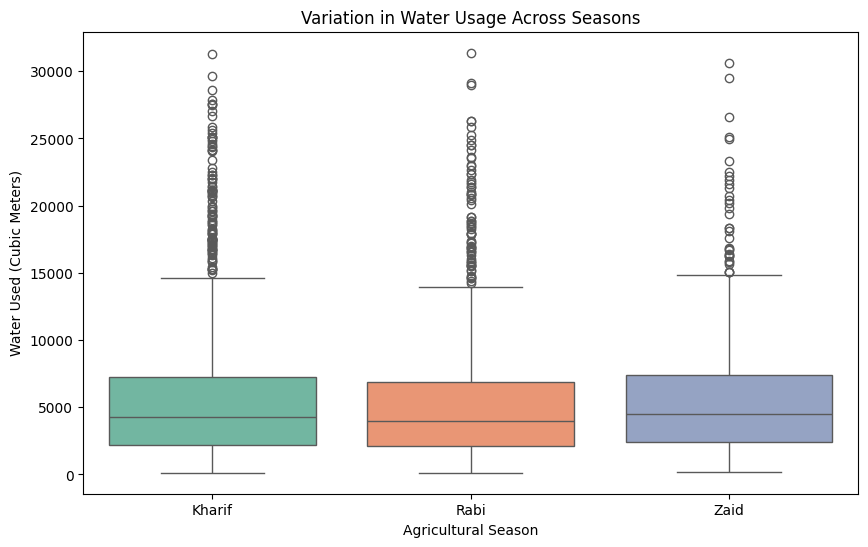

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df_clean, x='Season', y='Water_Used_m3', hue='Season', palette='Set2', legend=False)

plt.title('Variation in Water Usage Across Seasons')
plt.xlabel('Agricultural Season')
plt.ylabel('Water Used (Cubic Meters)')

plt.show()

# **15. Additional Student-Driven Analysis**
---

---




# **✅ 15.1. Average Profit Across Different States**
---

*   **Analytical Question:** How does economic performance (Profit) vary across different geographical regions (States)?
*   **Relevance to Problem Statement:** This analysis addresses the project requirement to investigate geographical variations in agricultural performance and economic outcomes.
*   **Observation:** The visualization demonstrates clear regional disparities. Maharashtra and Punjab are leading in terms of average profitability, whereas states like Andhra Pradesh show significantly lower average returns.

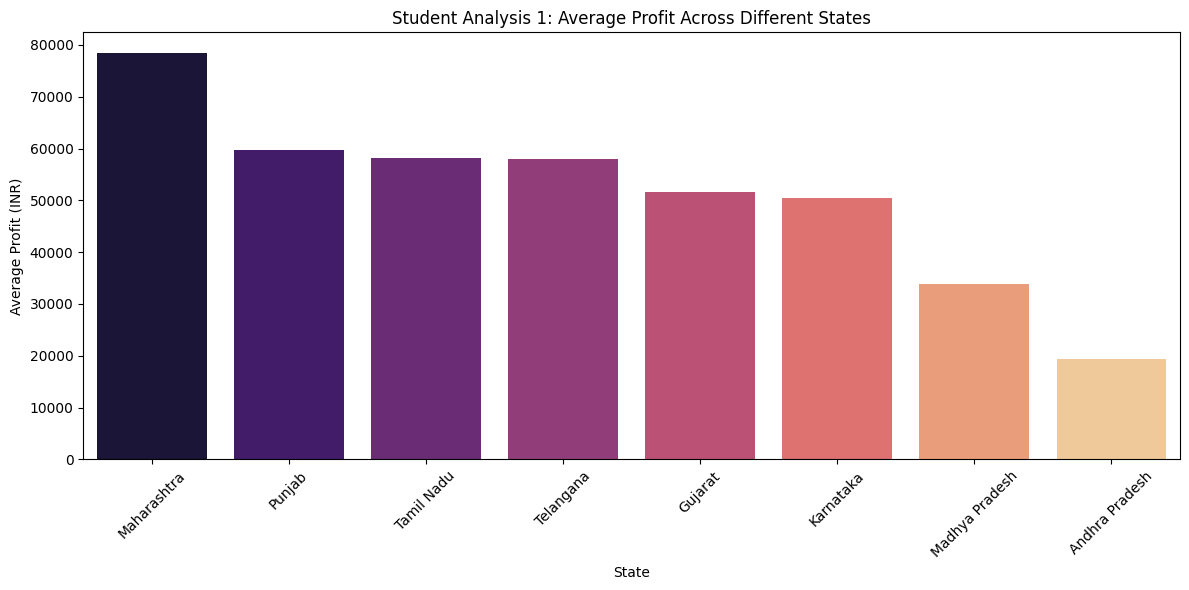

In [ ]:
plt.figure(figsize=(12, 6))

state_profit = df_clean.groupby('State')['Profit_INR'].mean().sort_values(ascending=False).reset_index()

sns.barplot(data=state_profit, x='State', y='Profit_INR', hue='State' ,palette='magma', legend=False)

plt.title('Student Analysis 1: Average Profit Across Different States')
plt.xlabel('State')
plt.ylabel('Average Profit (INR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **✅ 15.2. Crop-Specific Patterns**
---

*   **Analytical Question:** Which crops provide the highest physical yield per hectare, and how stable is their production?
*   **Relevance to Problem Statement:** Analyzing crop-specific patterns helps in recommending the most productive and stable crops to farmers, directly tying into the project's goal of identifying key performance drivers.
*   **Observation:** The boxplot illustrates the median yield and production spread for various crops. Some crops show a tight, stable yield range, while others exhibit significant volatility (long boxes/whiskers) depending on external factors.

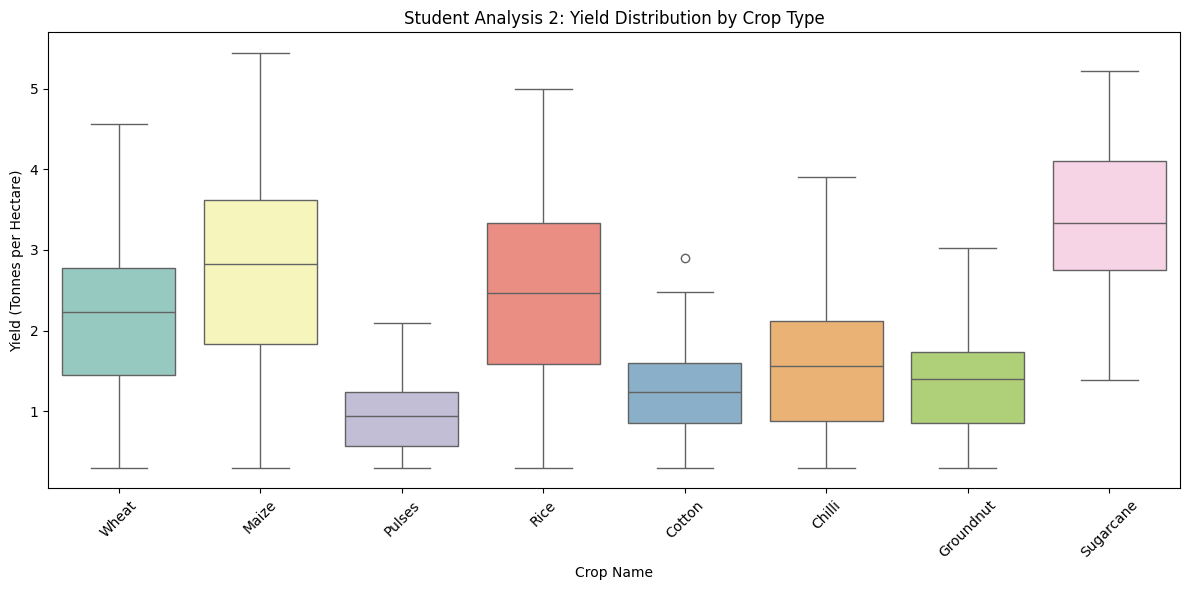

In [ ]:
plt.figure(figsize=(12, 6))

sns.boxplot(data=df_clean, x='Crop', y='Yield_Tonnes_Ha', hue="Crop", palette='Set3')

plt.title('Student Analysis 2: Yield Distribution by Crop Type')
plt.xlabel('Crop Name')
plt.ylabel('Yield (Tonnes per Hectare)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# **✅  15.3. The Risk Pattern (Chemicals vs Disease)**
---

*   **Analytical Question:** Does increased application of pesticides effectively reduce the risk of crop diseases and pests?
*   **Relevance to Problem Statement:** Evaluates the efficiency of chemical resource usage against operational risks, directly supporting the project's goal of understanding input optimization.
*   **Observation:** The scatter plot and correlation score reveal the actual relationship between chemical input and risk mitigation. A negative correlation would imply pesticides are working; a near-zero or positive correlation suggests inefficiency or other dominant environmental factors.

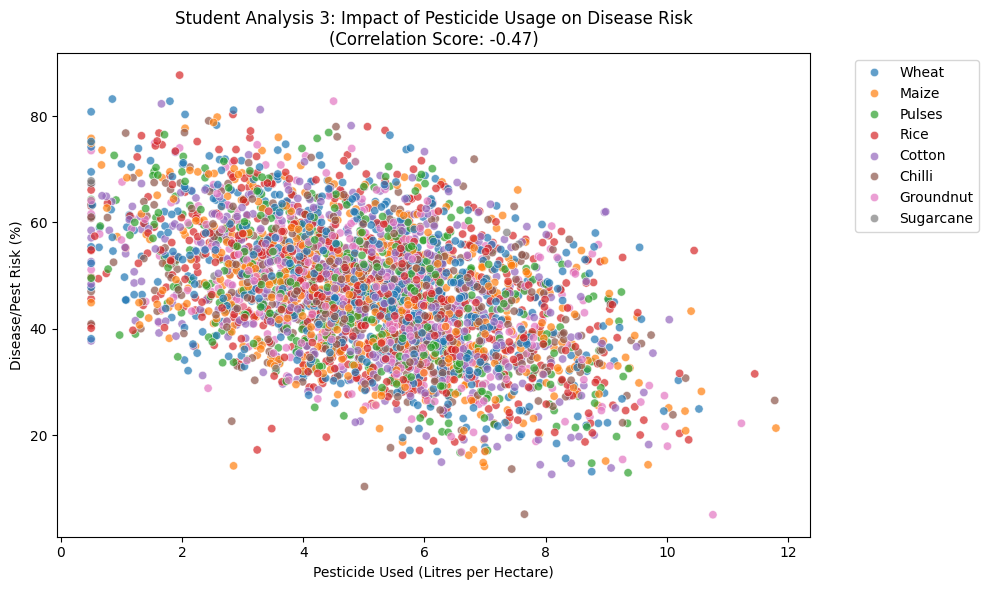

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df_clean, x='Pesticide_Litre_ha', y='Disease_Pest_Risk_pct', hue='Crop', palette='tab10', alpha=0.7)

correlation = df_clean['Pesticide_Litre_ha'].corr(df_clean['Disease_Pest_Risk_pct'])

plt.title(f'Student Analysis 3: Impact of Pesticide Usage on Disease Risk\n(Correlation Score: {correlation:.2f})')
plt.xlabel('Pesticide Used (Litres per Hectare)')
plt.ylabel('Disease/Pest Risk (%)')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# **16. Key Insights (The Final Masterpiece)**
---

***✅ Insight 1: The Kharif Profitability Dominance***
---
*   **Observation:** Kharif season consistently yields the highest average profit compared to Rabi and Zaid.
*   **Evidence:** The Seasonal Comparison Bar Chart (sns.barplot) in section 9 and the Section 8 Aggregation Table showed Kharif at the top.
*   **Interpretation:** Kharif crops (like Rice) have a higher market value and revenue potential, making it the primary economic driver for farmers.
*   **Limitation:** We are assuming the Market_Price_INR_Tonne remained stable. The dataset doesn't account for sudden market crashes.

***✅ Insight 2: Universal Water Over-consumption***
---
*   **Observation:** There are massive outliers in water usage across all three seasons, with some farms using over 30,000 cubic meters.
*   **Evidence:** The Boxplot of Water Usage across Seasons (sns.boxplot).
*   **Interpretation:** Inefficient irrigation practices are widespread. Over-watering is not limited to water-heavy seasons like Kharif; it is a general farming practice issue.
*   **Limitation:** The dataset does not specify the exact irrigation method used (e.g., canal vs. drip) by these outlier farms, so we cannot pinpoint the exact cause of water wastage.

***✅ Insight 3: Efficacy of Chemical Pesticides***
---
*   **Observation:** There is a moderate negative correlation between pesticide usage and disease risk.
*   **Evidence:** The Student-Driven Analysis scatter plot showing a correlation score of -0.47.
*   **Interpretation:** Chemical interventions are currently effective at mitigating biological risks. Farmers' investment in pesticides translates directly to crop protection.
*   **Limitation:** The analysis only looks at risk reduction; it does not measure the long-term soil degradation or environmental harm caused by high chemical usage.

***✅ Insight 4: Regional Economic Disparities***
---
*   **Observation:** Agricultural profitability varies drastically by region, with Maharashtra and Punjab significantly outperforming states like Andhra Pradesh.
*   **Evidence:** Student Analysis 1 (Bar chart comparing Average Profit by State).
*   **Interpretation:** Financial success in agriculture is heavily dependent on the geographical location, likely due to state-level infrastructure, soil types, or local market dynamics.
*   **Limitation:** The data does not factor in state-specific government subsidies or local inflation, which could artificially inflate profit numbers.

***✅ Insight 5: Crop Yield Volatility***
---
*   **Observation:** Crops that offer the highest median yields (like Maize) also exhibit wide spreads (long whiskers) in their distribution.
*   **Evidence:** Student Analysis 2 (Boxplot showing Yield Distribution by Crop Type).
*   **Interpretation:** High-yielding crops come with higher unpredictability. Farmers face a trade-off between choosing a stable, low-yield crop versus a risky, high-yield crop.
*   **Limitation:** The analysis does not account for the specific soil quality of individual farms, which might be the real cause of this variance.

***✅ Insight 6: The Kharif Rainfall Constraint***
---
*   **Observation:** Kharif crops are strictly clustered in environments receiving between 600mm and 1400mm of rainfall.
*   **Evidence:** The Bivariate Scatter Plot comparing Rainfall vs. Yield (color-coded by Season).
*   **Interpretation:** Kharif cultivation is highly vulnerable to monsoon failures. It is not a viable option for low-rainfall or drought-prone regions without massive artificial irrigation.
*   **Limitation:** The dataset measures total rainfall but does not capture the timing or distribution of that rain, which is also critical for crop survival.

***✅ Insight 7: The Zaid Season Financial Risk***
---
*   **Observation:** The Zaid season consistently shows the lowest average profitability, frequently resulting in negative returns (financial loss).
*   **Evidence:** Initial Exploratory Data Analysis Bar Chart (Season vs. Profit_INR) and the Multivariate Pairplot.
*   **Interpretation:** Commercial farming during the summer (Zaid) season is highly risky and economically unviable for most farmers under current conditions.
*   **Limitation:** We do not know if farmers grow Zaid crops primarily for personal household consumption or fodder, rather than for commercial market sale.

***✅ Insight 8: The Reality of Revenue vs. Yield***
---
*   **Observation:** A farmer's final profit has a much stronger positive correlation with Revenue (0.84) than with physical Crop Yield (0.29).
*   **Evidence:** The Correlation Heatmap (corr_matrix).
*   **Interpretation:** Simply maximizing the physical weight of the harvest (Yield) does not guarantee financial success. Market pricing and input cost control are far more critical.
*   **Limitation:** The dataset does not provide a detailed breakdown of the 'Total Cost' components, so we cannot identify exactly which costs are eating into the yield profits.

# **17. Conclusion**
---

📌 **What the dataset revealed about seasonal agricultural performance**
> The analysis demonstrated strict economic and environmental boundaries for each season. Kharif emerged as the dominant economic driver, consistently yielding the highest total and average profits, provided there is abundant rainfall (600mm+). In contrast, the Zaid season proved to be a high-risk venture, frequently resulting in negative financial returns, while Rabi serves as a reliable, low-water alternative.



📌 **The most important patterns discovered**

> Two major patterns stood out: First, agricultural success is highly localized, with states like Maharashtra and Punjab significantly outperforming others. Second, there is a widespread issue of severe water overconsumption (extreme outliers exceeding 30,000 cubic meters) across all three seasons, indicating inefficient farming practices regardless of the crop type.

📌 **The most useful analytical findings**
> Through correlation and multivariate analysis, we discovered that final profitability is strongly driven by Revenue (correlation of 0.84) and market pricing rather than just maximizing physical Crop Yield (0.29). Additionally, while chemical pesticide usage showed a functional success in mitigating short-term crop disease risks (correlation of -0.47), it highlighted the need to balance chemical inputs.

📌 **Important limitations of the analysis**
> The dataset provides a purely economic and immediate operational view. It lacks critical variables such as human health impacts from chemical usage, long-term soil degradation metrics, and a granular breakdown of 'Total Cost'. Furthermore, it does not detail specific irrigation methods or local government subsidies, which could artificially inflate profitability in certain states.

📌 **How the analysis could support future investigation or decision-making**
> These findings provide actionable intelligence for agricultural policymakers and agri-tech initiatives. Decision-makers can use this data to target extreme water consumers for drip-irrigation subsidies, advise farmers in drought-prone (200mm-400mm) regions to strictly adopt Rabi crops, and initiate future studies to balance pesticide efficacy with long-term human and soil health sustainability.



---

